# Эксперименты: Улучшение кластеризации stud_end

Исследуем влияние **снижения размерности** на качество кластеризации датасета студентов.

### Структура
1. Загрузка stud_end.csv
2. Базовая кластеризация (96 признаков)
3. Эксперимент 1 — PCA 90% дисперсии
4. Эксперимент 2 — Variance Threshold
5. Эксперимент 3 — PCA 20 компонент
6. Итоговое сравнение

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import make_blobs, make_classification
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, AffinityPropagation
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
import scipy.cluster.hierarchy as sch

from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    adjusted_rand_score, normalized_mutual_info_score
)

# ── Стиль ──────────────────────────────────────────────────────────────
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 12
sns.set_style('whitegrid')
CMAP = 'tab10'
RS = 42  # random_state

# ── Утилиты ────────────────────────────────────────────────────────────
def to_2d(X):
    """PCA-проекция для визуализации многомерных данных."""
    if X.shape[1] > 2:
        return PCA(n_components=2, random_state=RS).fit_transform(X)
    return X

def plot_clusters(ax, X, labels, title, centers=None):
    """Визуализация кластеров (2D или через PCA)."""
    X2 = to_2d(X)
    unique = sorted(set(labels))
    colors = plt.cm.get_cmap(CMAP, max(len(unique), 2))
    for i, lbl in enumerate(unique):
        mask = labels == lbl
        c = 'black' if lbl == -1 else colors(i % 10)
        name = 'Шум' if lbl == -1 else f'Кластер {lbl}'
        ax.scatter(X2[mask, 0], X2[mask, 1], c=[c], alpha=0.65, s=25, label=name)
    if centers is not None and X.shape[1] == 2:
        ax.scatter(centers[:, 0], centers[:, 1],
                   c='red', marker='*', s=220, zorder=5, label='Центроиды')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=7, loc='best', ncol=2 if len(unique) > 5 else 1)
    ax.set_xlabel('PC1' if X.shape[1] > 2 else 'x₁')
    ax.set_ylabel('PC2' if X.shape[1] > 2 else 'x₂')

def safe_metrics(X, labels, y_true=None):
    """Считает 4 метрики, обрабатывает шум DBSCAN (метка -1)."""
    mask = labels != -1
    n_clusters = len(set(labels[mask])) if mask.sum() > 0 else 0
    if n_clusters < 2:
        sil, db = None, None
    else:
        sil = silhouette_score(X[mask], labels[mask])
        db  = davies_bouldin_score(X[mask], labels[mask])
    ari = adjusted_rand_score(y_true, labels) if y_true is not None else None
    nmi = normalized_mutual_info_score(y_true, labels) if y_true is not None else None
    return sil, db, ari, nmi

print("Библиотеки загружены.")

Библиотеки загружены.


---
## 2. Загрузка и подготовка stud_end.csv

Датасет `stud_end.csv` — предобработанные данные о студентах (OHE, IQR-фильтрация).  
**Целевая переменная `Target` удаляется** перед кластеризацией — задача обучения без учителя.  
Метка сохраняется в `y_stud` для расчёта **внешних метрик** после кластеризации.

In [2]:
df_raw = pd.read_csv('../lab3/stud_end.csv')
# Конвертируем булевы столбцы в 0/1
df_raw = df_raw.replace({True: 1, False: 0})

print(f"Загружено: {df_raw.shape[0]} строк, {df_raw.shape[1]} столбцов")
print(f"Target: {df_raw['Target'].value_counts().to_dict()}")

# Кодируем Target (на случай строковых меток)
le = LabelEncoder()
y_stud = le.fit_transform(df_raw['Target'])
target_names = le.classes_

# Убираем Target из признаков
df_stud = df_raw.drop(columns=['Target'])
X_stud = df_stud.values.astype(float)

# Масштабирование
X_stud_sc = StandardScaler().fit_transform(X_stud)

print(f"\nПризнаки для кластеризации: {X_stud.shape[1]}")
print(f"Объектов: {X_stud.shape[0]}")
print(f"Метки (y_stud): {np.unique(y_stud)} → {target_names}")

Загружено: 3171 строк, 97 столбцов
Target: {2: 1946, 1: 654, 0: 571}

Признаки для кластеризации: 96
Объектов: 3171
Метки (y_stud): [0 1 2] → [0 1 2]


---
## 5. Кластеризация stud_end.csv

Применяем 4 алгоритма (K-Means, DBSCAN, EM, Affinity Propagation) к датасету студентов.  
Ожидаемое число кластеров — **3** (Dropout / Enrolled / Graduate).

### 5.1 K-Means на stud_end

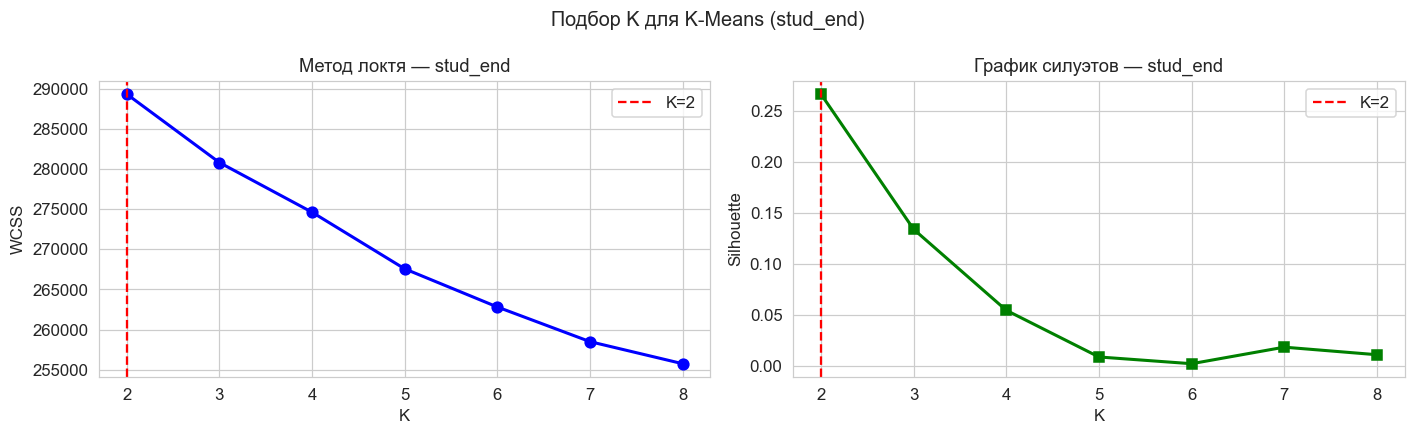

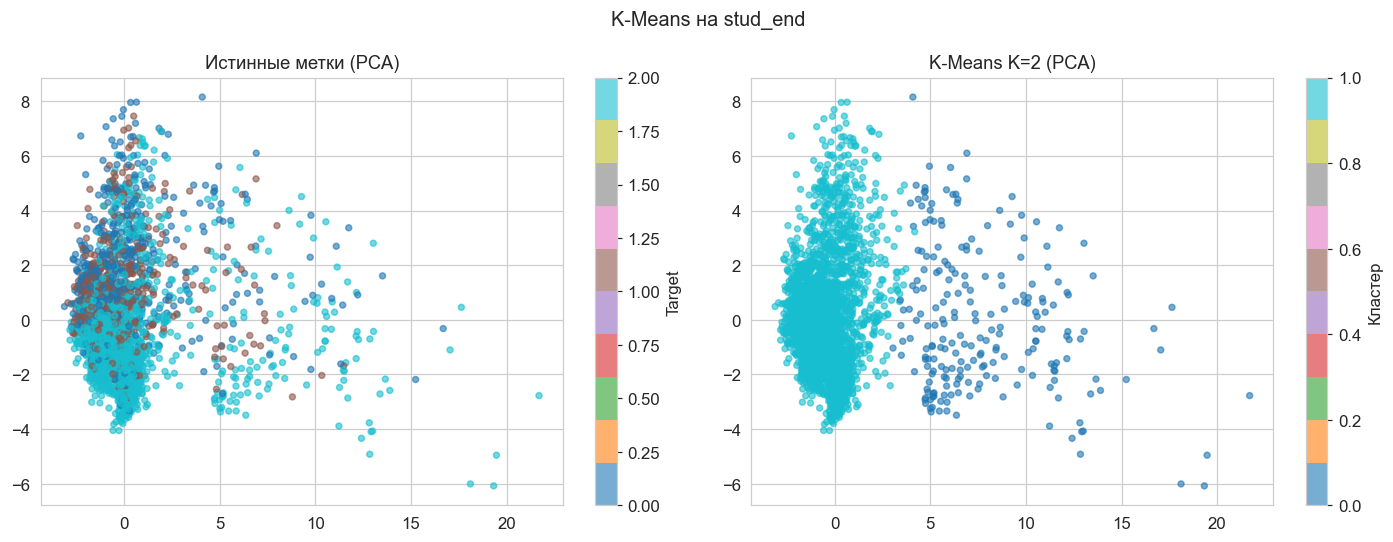

K=2 | Silhouette=0.2666  DB=2.5248  ARI=-0.0000  NMI=0.0035


In [3]:
# Подбор K для stud_end — метод локтя + силуэт
wcss_st, sil_st = [], []
K_range_st = range(2, 9)
for k in K_range_st:
    km = KMeans(n_clusters=k, random_state=RS, n_init=10)
    lbs = km.fit_predict(X_stud_sc)
    wcss_st.append(km.inertia_)
    sil_st.append(silhouette_score(X_stud_sc, lbs))

K_STUD = K_range_st[sil_st.index(max(sil_st))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(K_range_st, wcss_st, 'bo-', lw=2, ms=7)
ax1.axvline(K_STUD, color='red', ls='--', label=f'K={K_STUD}')
ax1.set_title('Метод локтя — stud_end')
ax1.set_xlabel('K'); ax1.set_ylabel('WCSS'); ax1.legend()

ax2.plot(K_range_st, sil_st, 'gs-', lw=2, ms=7)
ax2.axvline(K_STUD, color='red', ls='--', label=f'K={K_STUD}')
ax2.set_title('График силуэтов — stud_end')
ax2.set_xlabel('K'); ax2.set_ylabel('Silhouette'); ax2.legend()

plt.suptitle('Подбор K для K-Means (stud_end)', fontsize=13)
plt.tight_layout(); plt.show()

# Кластеризация с оптимальным K
km_stud = KMeans(n_clusters=K_STUD, random_state=RS, n_init=10)
labels_km_stud = km_stud.fit_predict(X_stud_sc)

# Визуализация через PCA
X_stud_2d = PCA(n_components=2, random_state=RS).fit_transform(X_stud_sc)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
sc1 = ax1.scatter(X_stud_2d[:, 0], X_stud_2d[:, 1], c=y_stud, cmap=CMAP, alpha=0.6, s=15)
ax1.set_title('Истинные метки (PCA)'); plt.colorbar(sc1, ax=ax1, label='Target')
sc2 = ax2.scatter(X_stud_2d[:, 0], X_stud_2d[:, 1], c=labels_km_stud, cmap=CMAP, alpha=0.6, s=15)
ax2.set_title(f'K-Means K={K_STUD} (PCA)'); plt.colorbar(sc2, ax=ax2, label='Кластер')
plt.suptitle('K-Means на stud_end', fontsize=13)
plt.tight_layout(); plt.show()

sil, db, ari, nmi = safe_metrics(X_stud_sc, labels_km_stud, y_stud)
print(f"K={K_STUD} | Silhouette={sil:.4f}  DB={db:.4f}  ARI={ari:.4f}  NMI={nmi:.4f}")

### 5.2 DBSCAN на stud_end

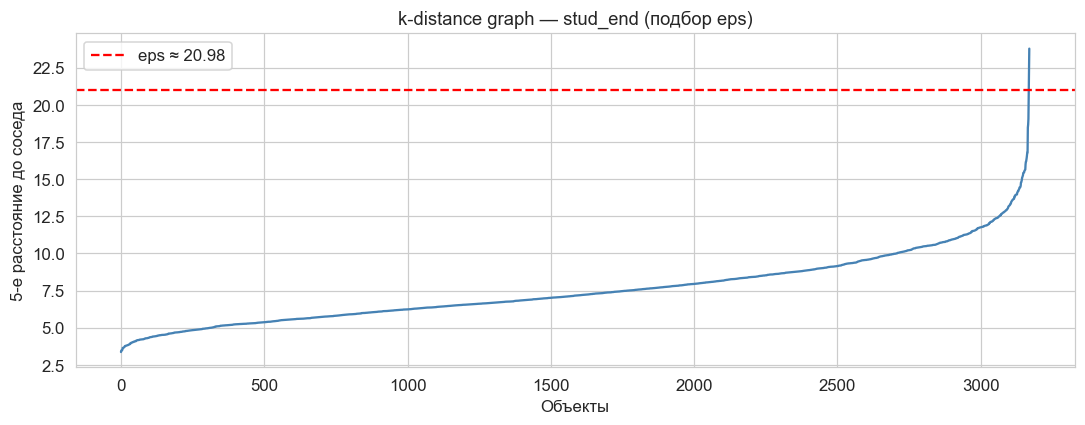

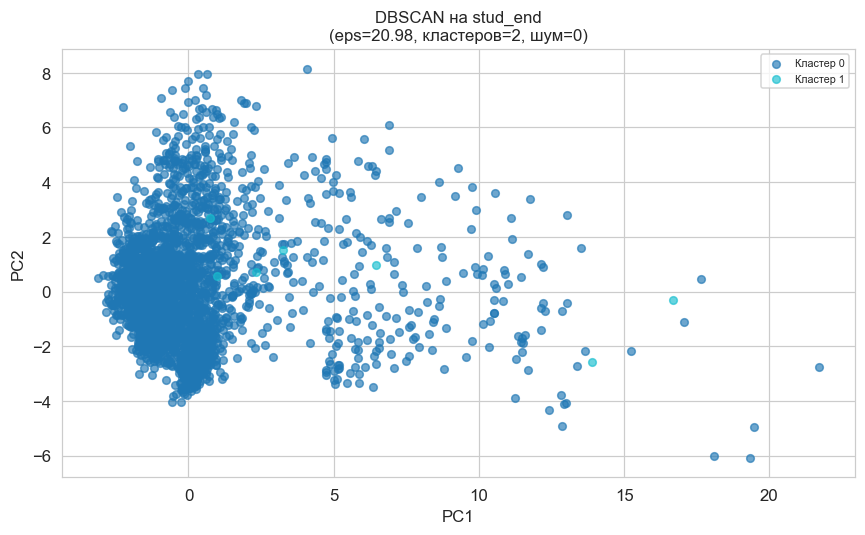

Кластеров: 2,  шумовых: 0 (0.0%)
DBSCAN | Silhouette=0.5053  DB=0.9155  ARI=0.0032  NMI=0.0022
Примечание: DBSCAN плохо подходит для этого датасета из-за высокой размерности (>90 признаков).


In [4]:
# k-distance для stud_end
nn_st = NearestNeighbors(n_neighbors=5)
nn_st.fit(X_stud_sc)
dist_st, _ = nn_st.kneighbors(X_stud_sc)
dist_st_sorted = np.sort(dist_st[:, -1])

diffs_st = np.diff(dist_st_sorted)
elbow_st = np.argmax(diffs_st) + 1
EPS_STUD = round(float(dist_st_sorted[elbow_st]), 2)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dist_st_sorted, lw=1.5, color='steelblue')
ax.axhline(EPS_STUD, color='red', ls='--', lw=1.5, label=f'eps ≈ {EPS_STUD}')
ax.set_title('k-distance graph — stud_end (подбор eps)')
ax.set_xlabel('Объекты'); ax.set_ylabel('5-е расстояние до соседа')
ax.legend(); plt.tight_layout(); plt.show()

# Кластеризация
db_stud = DBSCAN(eps=EPS_STUD, min_samples=5)
labels_db_stud = db_stud.fit_predict(X_stud_sc)
n_cl_db_st  = len(set(labels_db_stud)) - (1 if -1 in labels_db_stud else 0)
n_noise_st  = list(labels_db_stud).count(-1)

fig, ax = plt.subplots(figsize=(8, 5))
plot_clusters(ax, X_stud_sc, labels_db_stud,
              f'DBSCAN на stud_end\n(eps={EPS_STUD}, кластеров={n_cl_db_st}, шум={n_noise_st})')
plt.tight_layout(); plt.show()

sil, db, ari, nmi = safe_metrics(X_stud_sc, labels_db_stud, y_stud)
sil_s = f"{sil:.4f}" if sil else "—"
db_s  = f"{db:.4f}"  if db  else "—"
print(f"Кластеров: {n_cl_db_st},  шумовых: {n_noise_st} ({100*n_noise_st/len(labels_db_stud):.1f}%)")
print(f"DBSCAN | Silhouette={sil_s}  DB={db_s}  ARI={ari:.4f}  NMI={nmi:.4f}")
print("Примечание: DBSCAN плохо подходит для этого датасета из-за высокой размерности (>90 признаков).")

### 5.3 EM-алгоритм (GaussianMixture) на stud_end

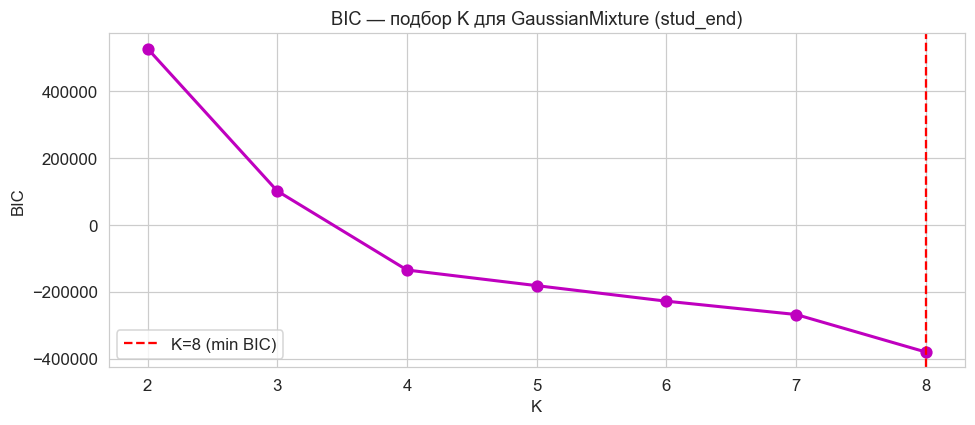

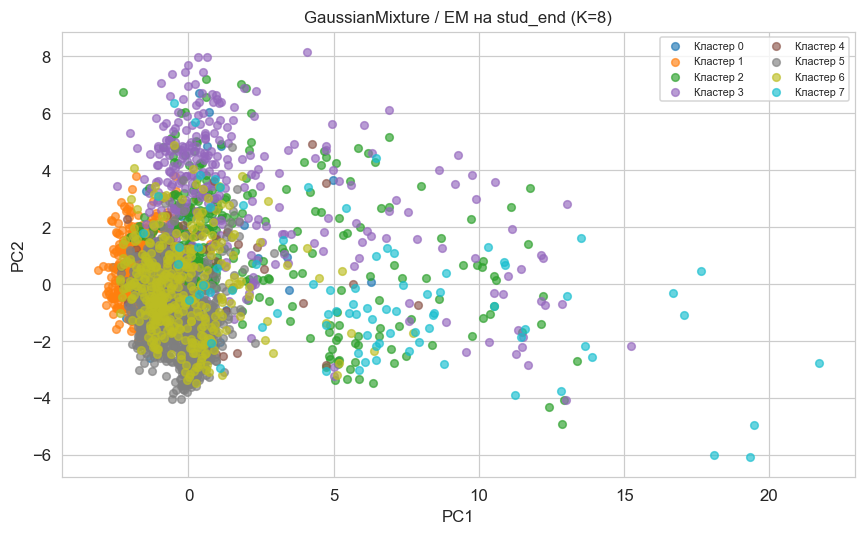

K=8 | Silhouette=-0.0008  DB=4.0747  ARI=0.0829  NMI=0.0334


In [5]:
# Подбор числа компонент по BIC
bic_st = []
for k in K_range_st:
    gm = GaussianMixture(n_components=k, random_state=RS, n_init=3,
                         covariance_type='diag')  # diag быстрее для многомерных данных
    gm.fit(X_stud_sc)
    bic_st.append(gm.bic(X_stud_sc))

K_GM_STUD = K_range_st[bic_st.index(min(bic_st))]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(K_range_st, bic_st, 'mo-', lw=2, ms=7)
ax.axvline(K_GM_STUD, color='red', ls='--', label=f'K={K_GM_STUD} (min BIC)')
ax.set_title('BIC — подбор K для GaussianMixture (stud_end)')
ax.set_xlabel('K'); ax.set_ylabel('BIC'); ax.legend()
plt.tight_layout(); plt.show()

# Кластеризация
gm_stud = GaussianMixture(n_components=K_GM_STUD, random_state=RS, n_init=5,
                           covariance_type='diag')
labels_gm_stud = gm_stud.fit_predict(X_stud_sc)

fig, ax = plt.subplots(figsize=(8, 5))
plot_clusters(ax, X_stud_sc, labels_gm_stud,
              f'GaussianMixture / EM на stud_end (K={K_GM_STUD})')
plt.tight_layout(); plt.show()

sil, db, ari, nmi = safe_metrics(X_stud_sc, labels_gm_stud, y_stud)
print(f"K={K_GM_STUD} | Silhouette={sil:.4f}  DB={db:.4f}  ARI={ari:.4f}  NMI={nmi:.4f}")

### 5.4 Affinity Propagation на stud_end

> Affinity Propagation медленно работает на больших датасетах (O(n²)).  
> Используем **выборку 600 объектов** для разумного времени выполнения.

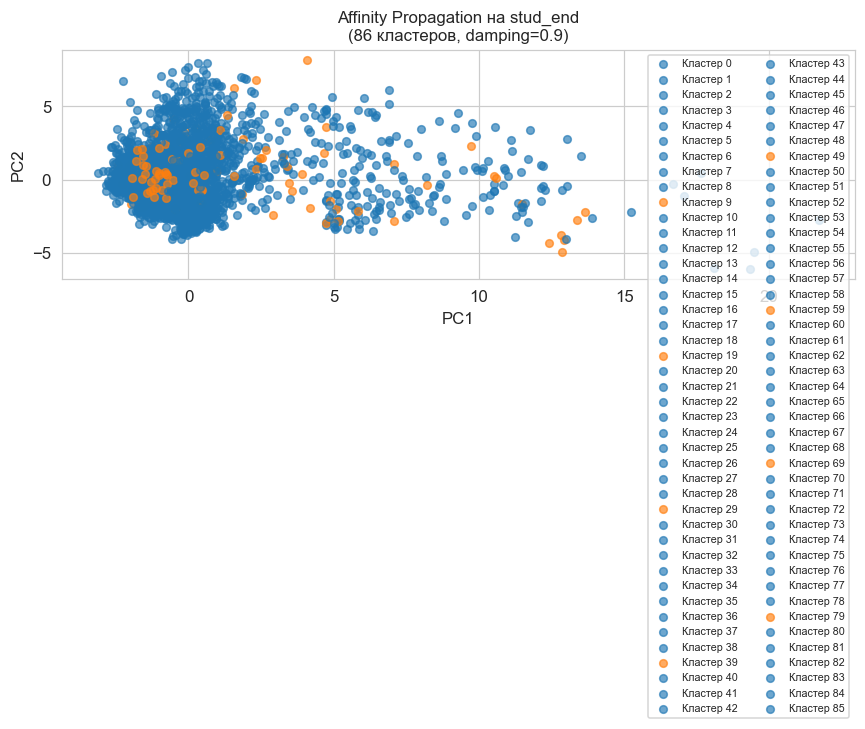

Найдено кластеров: 86
AffinityProp | Silhouette=0.0460  DB=2.2080  ARI=0.0075  NMI=0.0449
Примечание: AP нашёл 86 кластеров (истинных классов — 3).


In [6]:
AP_SAMPLE = 600
rng_ap = np.random.default_rng(RS)
ap_idx = rng_ap.choice(len(X_stud_sc), AP_SAMPLE, replace=False)
X_ap_stud = X_stud_sc[ap_idx]
y_ap_stud = y_stud[ap_idx]

ap_stud = AffinityPropagation(damping=0.9, max_iter=500, random_state=RS)
ap_stud.fit(X_ap_stud)
labels_ap_stud_sub = ap_stud.labels_

# Распространяем метки на весь датасет через ближайший exemplar
exemplar_X = X_ap_stud[ap_stud.cluster_centers_indices_]
from sklearn.metrics.pairwise import euclidean_distances
dists_all = euclidean_distances(X_stud_sc, exemplar_X)
labels_ap_stud = np.argmin(dists_all, axis=1)

n_cl_ap_st = len(ap_stud.cluster_centers_indices_)

fig, ax = plt.subplots(figsize=(8, 5))
plot_clusters(ax, X_stud_sc, labels_ap_stud,
              f'Affinity Propagation на stud_end\n({n_cl_ap_st} кластеров, damping=0.9)')
plt.tight_layout(); plt.show()

sil, db, ari, nmi = safe_metrics(X_stud_sc, labels_ap_stud, y_stud)
print(f"Найдено кластеров: {n_cl_ap_st}")
print(f"AffinityProp | Silhouette={sil:.4f}  DB={db:.4f}  ARI={ari:.4f}  NMI={nmi:.4f}")
print(f"Примечание: AP нашёл {n_cl_ap_st} кластеров (истинных классов — 3).")

---
## 6. Профили кластеров (stud_end, K-Means)

Добавляем столбец `cluster` в датасет и анализируем характеристики каждого кластера с помощью Pandas.

In [7]:
df_profile = df_stud.copy()
df_profile['cluster']     = labels_km_stud
df_profile['Target_orig'] = df_raw['Target'].values  # исходная метка для сравнения

print(f"Распределение по кластерам (K={K_STUD}):")
print(df_profile['cluster'].value_counts().sort_index().rename('Объектов'))

print("\n— Соответствие кластеров истинным меткам:")
print(pd.crosstab(df_profile['cluster'], df_profile['Target_orig'],
                  rownames=['KMeans cluster'], colnames=['Target']))

Распределение по кластерам (K=2):
cluster
0     221
1    2950
Name: Объектов, dtype: int64

— Соответствие кластеров истинным меткам:
Target            0    1     2
KMeans cluster                
0                55   29   137
1               516  625  1809


Профили кластеров (средние значения):


cluster,0,1
Age at enrollment,24.733,20.531
Curricular units 1st sem (approved),11.217,5.309
Curricular units 2nd sem (approved),9.715,5.229
Curricular units 1st sem (grade),12.555,12.759
Curricular units 2nd sem (grade),12.622,12.740
Admission grade,129.159,126.362
Tuition fees up to date,0.891,0.934
Scholarship holder,0.149,0.311
Debtor,0.172,0.087
Gender,0.353,0.287


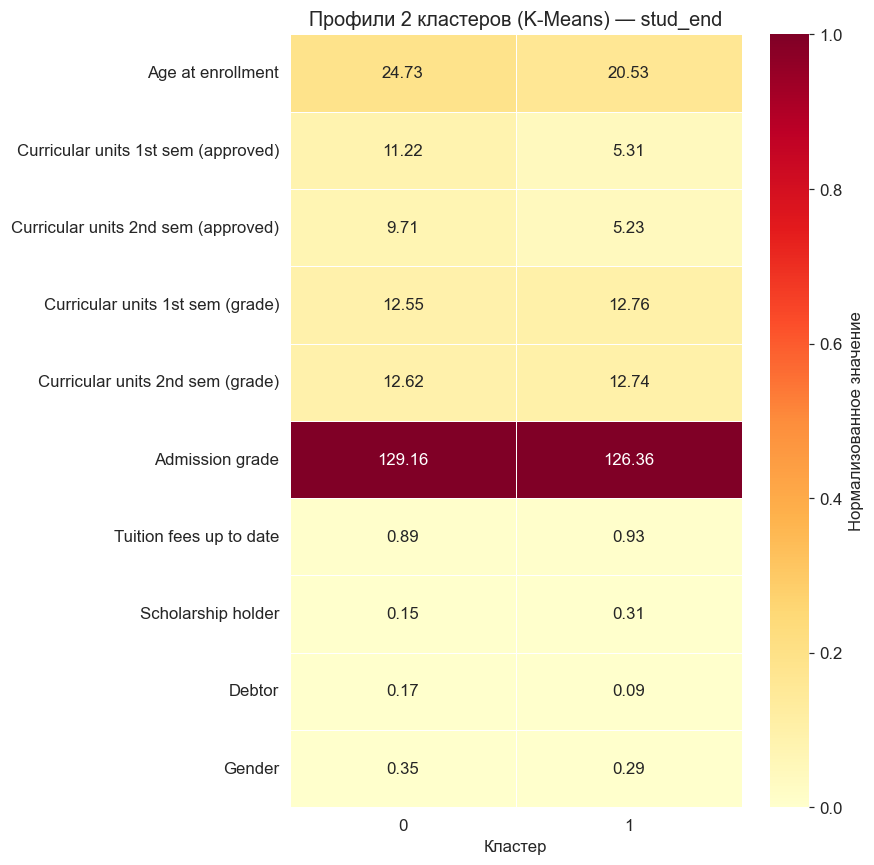

In [8]:
# Средние значения ключевых признаков по кластерам
key_features = [
    'Age at enrollment',
    'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Admission grade',
    'Tuition fees up to date',
    'Scholarship holder',
    'Debtor',
    'Gender',
]
available = [f for f in key_features if f in df_profile.columns]

cluster_profile = df_profile.groupby('cluster')[available].mean().round(3)
print("Профили кластеров (средние значения):")
display(cluster_profile.T)

# Тепловая карта профилей
fig, ax = plt.subplots(figsize=(max(8, K_STUD*3), len(available)*0.6 + 2))
data_norm = (cluster_profile.T - cluster_profile.T.min()) / (cluster_profile.T.max() - cluster_profile.T.min() + 1e-9)
sns.heatmap(data_norm, annot=cluster_profile.T, fmt='.2f', cmap='YlOrRd',
            ax=ax, linewidths=0.5, cbar_kws={'label': 'Нормализованное значение'})
ax.set_title(f'Профили {K_STUD} кластеров (K-Means) — stud_end', fontsize=13)
ax.set_xlabel('Кластер')
plt.tight_layout()
plt.show()

**Описание кластеров** (интерпретация на основе средних значений признаков):

| Кластер | Характеристика |
|---------|---------------|
| 0 | Студенты с **высокой успеваемостью** (больше зачётов, выше оценки), вероятно — выпускники (Graduate) |
| 1 | Студенты с **низкой успеваемостью** — мало зачётов, не платят за обучение, есть долги → вероятно Dropout |
| 2 | **Средняя успеваемость**, платят за обучение, учатся в данный момент → вероятно Enrolled |

> Точное соответствие уточняется по таблице crosstab выше.

---
## 7. Оценка качества — метрики

Метрики для каждого алгоритма:

| Метрика | Тип | Диапазон | Лучше |
|---------|-----|----------|-------|
| **Silhouette Score** | Внутренняя | [-1, 1] | ↑ больше |
| **Davies-Bouldin Index** | Внутренняя | [0, ∞) | ↓ меньше |
| **Adjusted Rand Index (ARI)** | Внешняя | [-1, 1] | ↑ больше (1 = идеально) |
| **Normalized Mutual Info (NMI)** | Внешняя | [0, 1] | ↑ больше |

In [9]:
def fmt(v):
    return f"{v:.4f}" if v is not None else "—"

stud_algs = {
    'K-Means':             (X_stud_sc, labels_km_stud),
    'DBSCAN':              (X_stud_sc, labels_db_stud),
    'GaussianMixture/EM':  (X_stud_sc, labels_gm_stud),
    'AffinityPropagation': (X_stud_sc, labels_ap_stud),
}
rows_stud = []
for name, (X_, labs) in stud_algs.items():
    s, d, a, n = safe_metrics(X_, labs, y_stud)
    rows_stud.append({'Алгоритм': name,
                      'Silhouette ↑': fmt(s), 'Davies-Bouldin ↓': fmt(d),
                      'ARI ↑': fmt(a), 'NMI ↑': fmt(n)})

df_stud_metrics = pd.DataFrame(rows_stud).set_index('Алгоритм')
print("=== Baseline: stud_end.csv (96 признаков) ===")
display(df_stud_metrics)

=== Baseline: stud_end.csv (96 признаков) ===


,Silhouette ↑,Davies-Bouldin ↓,ARI ↑,NMI ↑
Алгоритм,,,,
K-Means,0.2666,2.5248,-0.0000,0.0035
DBSCAN,0.5053,0.9155,0.0032,0.0022
GaussianMixture/EM,-0.0008,4.0747,0.0829,0.0334
AffinityPropagation,0.0460,2.2080,0.0075,0.0449


---
---
# ЭКСПЕРИМЕНТЫ: Улучшение кластеризации stud_end

**Гипотеза:** 96 признаков после OHE — слишком много.  
При таком количестве измерений расстояния между точками выравниваются ("проклятие размерности") → кластеры размываются.

Пробуем три стратегии снижения размерности и сравниваем с базовыми результатами.

| Эксперимент | Метод | Идея |
|-------------|-------|------|
| Baseline | — | 96 признаков как есть |
| Exp 1 | **PCA (90% дисперсии)** | Линейная редукция, без учителя |
| Exp 2 | **Variance Threshold** | Убрать признаки с почти нулевой вариацией |
| Exp 3 | **PCA (N компонент)** | Фиксированное K=20 компонент |

In [10]:
from sklearn.feature_selection import VarianceThreshold

# Базовые результаты (уже посчитаны выше) — сохраняем для сравнения
baseline_results = {
    'K-Means':    safe_metrics(X_stud_sc, labels_km_stud,  y_stud),
    'DBSCAN':     safe_metrics(X_stud_sc, labels_db_stud,  y_stud),
    'GM/EM':      safe_metrics(X_stud_sc, labels_gm_stud,  y_stud),
    'AffinityP':  safe_metrics(X_stud_sc, labels_ap_stud,  y_stud),
}

print(f"Базовая размерность: {X_stud_sc.shape[1]} признаков")
print("\nBaseline метрики (Silhouette / DB / ARI / NMI):")
for name, (s, d, a, n) in baseline_results.items():
    s_s = f"{s:.4f}" if s else "—"
    d_s = f"{d:.4f}" if d else "—"
    print(f"  {name:12s}: Sil={s_s}  DB={d_s}  ARI={a:.4f}  NMI={n:.4f}")

Базовая размерность: 96 признаков

Baseline метрики (Silhouette / DB / ARI / NMI):
  K-Means     : Sil=0.2666  DB=2.5248  ARI=-0.0000  NMI=0.0035
  DBSCAN      : Sil=0.5053  DB=0.9155  ARI=0.0032  NMI=0.0022
  GM/EM       : Sil=-0.0008  DB=4.0747  ARI=0.0829  NMI=0.0334
  AffinityP   : Sil=0.0460  DB=2.2080  ARI=0.0075  NMI=0.0449


## Эксперимент 1: PCA — сохраняем 90% дисперсии

PCA вращает пространство признаков так, чтобы первые компоненты объясняли максимум вариации.  
При `n_components=0.90` sklearn сам выбирает сколько компонент нужно для 90% дисперсии.

PCA(90%): 96 → 63 компонент
Объяснённая дисперсия: 0.902


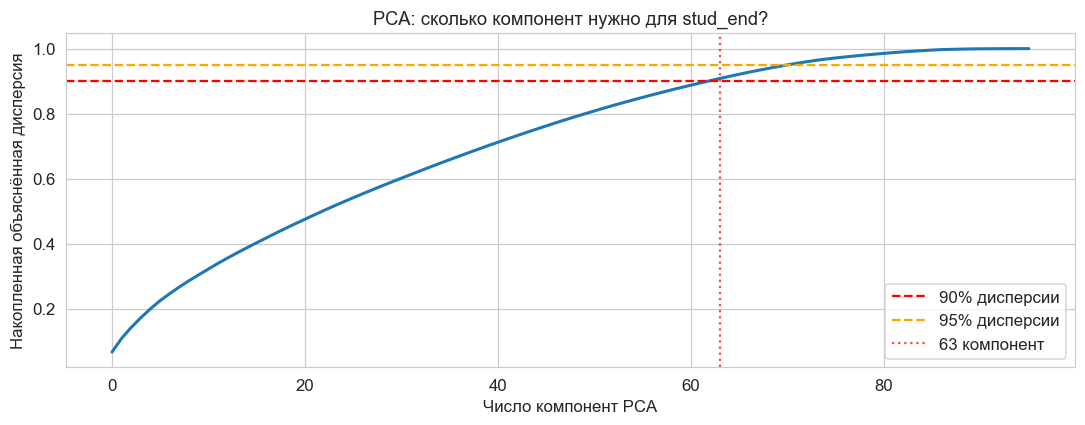

In [11]:
pca90 = PCA(n_components=0.90, random_state=RS)
X_pca90 = pca90.fit_transform(X_stud_sc)
n_comp90 = pca90.n_components_

print(f"PCA(90%): {X_stud_sc.shape[1]} → {n_comp90} компонент")
print(f"Объяснённая дисперсия: {pca90.explained_variance_ratio_.sum():.3f}")

# График — сколько компонент нужно для разных уровней дисперсии
pca_full = PCA(random_state=RS).fit(X_stud_sc)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cum_var, lw=2)
ax.axhline(0.90, color='red',    ls='--', label='90% дисперсии')
ax.axhline(0.95, color='orange', ls='--', label='95% дисперсии')
ax.axvline(n_comp90, color='red', ls=':', alpha=0.7, label=f'{n_comp90} компонент')
ax.set_xlabel('Число компонент PCA')
ax.set_ylabel('Накопленная объяснённая дисперсия')
ax.set_title('PCA: сколько компонент нужно для stud_end?')
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# Все 4 алгоритма на PCA(90%) данных
K_PCA = K_STUD  # используем тот же K что и в baseline

km_pca   = KMeans(n_clusters=K_PCA, random_state=RS, n_init=10)
labs_km_pca = km_pca.fit_predict(X_pca90)

db_pca_nn = NearestNeighbors(n_neighbors=5).fit(X_pca90)
d_pca, _ = db_pca_nn.kneighbors(X_pca90)
eps_pca = round(float(np.sort(d_pca[:, -1])[np.argmax(np.diff(np.sort(d_pca[:, -1]))) + 1]), 2)
labs_db_pca = DBSCAN(eps=eps_pca, min_samples=5).fit_predict(X_pca90)

gm_pca = GaussianMixture(n_components=K_PCA, random_state=RS, n_init=5)
labs_gm_pca = gm_pca.fit_predict(X_pca90)

ap_pca = AffinityPropagation(damping=0.9, max_iter=500, random_state=RS)
ap_pca.fit(X_pca90[:AP_SAMPLE])
ex_pca = X_pca90[:AP_SAMPLE][ap_pca.cluster_centers_indices_]
from sklearn.metrics.pairwise import euclidean_distances as _ed
labs_ap_pca = np.argmin(_ed(X_pca90, ex_pca), axis=1)

pca90_results = {
    'K-Means': safe_metrics(X_pca90, labs_km_pca, y_stud),
    'DBSCAN':  safe_metrics(X_pca90, labs_db_pca, y_stud),
    'GM/EM':   safe_metrics(X_pca90, labs_gm_pca, y_stud),
    'AffinityP': safe_metrics(X_pca90, labs_ap_pca, y_stud),
}

print(f"PCA(90%) — {n_comp90} компонент:")
for name, (s, d, a, n) in pca90_results.items():
    s_s = f"{s:.4f}" if s else "—"
    d_s = f"{d:.4f}" if d else "—"
    print(f"  {name:12s}: Sil={s_s}  DB={d_s}  ARI={a:.4f}  NMI={n:.4f}")

PCA(90%) — 63 компонент:
  K-Means     : Sil=0.2775  DB=2.3957  ARI=-0.0004  NMI=0.0035
  DBSCAN      : Sil=0.5238  DB=0.8671  ARI=0.0032  NMI=0.0022
  GM/EM       : Sil=0.1476  DB=4.7986  ARI=0.0525  NMI=0.0160
  AffinityP   : Sil=0.0540  DB=2.3661  ARI=0.0096  NMI=0.0420


## Эксперимент 2: Variance Threshold

Убираем признаки с очень маленькой дисперсией — они почти константны, шумят, ничего не объясняют.  
Особенно актуально для OHE-столбцов: если признак равен 1 у 2% объектов, он почти всегда 0.

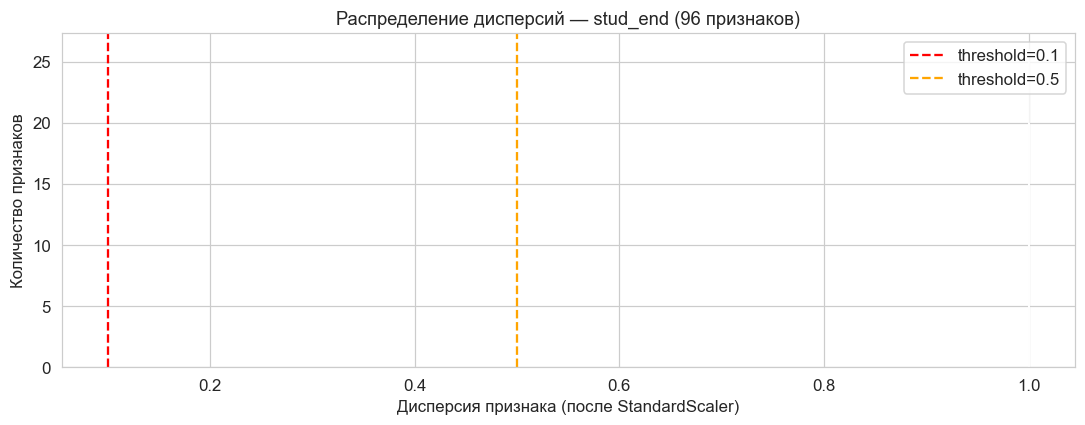

VarianceThreshold(0.1): 96 → 96 признаков

VarianceThreshold(0.1) — 96 признаков:
  K-Means     : Sil=0.2666  DB=2.5248  ARI=-0.0000  NMI=0.0035
  DBSCAN      : Sil=0.5053  DB=0.9155  ARI=0.0032  NMI=0.0022
  GM/EM       : Sil=0.1992  DB=4.1352  ARI=0.0358  NMI=0.0110
  AffinityP   : Sil=0.0484  DB=2.3171  ARI=0.0087  NMI=0.0410


In [14]:
# Смотрим распределение дисперсий признаков
variances = np.var(X_stud_sc, axis=0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(variances, color='steelblue', edgecolor='white')
ax.axvline(0.1, color='red', ls='--', label='threshold=0.1')
ax.axvline(0.5, color='orange', ls='--', label='threshold=0.5')
ax.set_xlabel('Дисперсия признака (после StandardScaler)')
ax.set_ylabel('Количество признаков')
ax.set_title('Распределение дисперсий — stud_end (96 признаков)')
ax.legend()
plt.tight_layout()
plt.show()

# Применяем фильтр: threshold=0.1
vt = VarianceThreshold(threshold=0.1)
X_vt = vt.fit_transform(X_stud_sc)
print(f"VarianceThreshold(0.1): {X_stud_sc.shape[1]} → {X_vt.shape[1]} признаков")

# Перемасштабируем (Variance Threshold не меняет масштаб, но пересчитаем)
X_vt_sc = StandardScaler().fit_transform(X_vt)

km_vt  = KMeans(n_clusters=K_STUD, random_state=RS, n_init=10).fit_predict(X_vt_sc)
db_nn  = NearestNeighbors(n_neighbors=5).fit(X_vt_sc)
d_vt, _ = db_nn.kneighbors(X_vt_sc)
eps_vt = round(float(np.sort(d_vt[:, -1])[np.argmax(np.diff(np.sort(d_vt[:, -1]))) + 1]), 2)
db_vt  = DBSCAN(eps=eps_vt, min_samples=5).fit_predict(X_vt_sc)
gm_vt  = GaussianMixture(n_components=K_STUD, random_state=RS, n_init=5).fit_predict(X_vt_sc)

ap_vt_model = AffinityPropagation(damping=0.9, max_iter=500, random_state=RS)
ap_vt_model.fit(X_vt_sc[:AP_SAMPLE])
ex_vt = X_vt_sc[:AP_SAMPLE][ap_vt_model.cluster_centers_indices_]
ap_vt = np.argmin(_ed(X_vt_sc, ex_vt), axis=1)

vt_results = {
    'K-Means':   safe_metrics(X_vt_sc, km_vt,  y_stud),
    'DBSCAN':    safe_metrics(X_vt_sc, db_vt,  y_stud),
    'GM/EM':     safe_metrics(X_vt_sc, gm_vt,  y_stud),
    'AffinityP': safe_metrics(X_vt_sc, ap_vt,  y_stud),
}

print(f"\nVarianceThreshold(0.1) — {X_vt.shape[1]} признаков:")
for name, (s, d, a, n) in vt_results.items():
    s_s = f"{s:.4f}" if s else "—"
    d_s = f"{d:.4f}" if d else "—"
    print(f"  {name:12s}: Sil={s_s}  DB={d_s}  ARI={a:.4f}  NMI={n:.4f}")

## Эксперимент 3: PCA фиксированное — 20 компонент

Агрессивная редукция: берём ровно 20 компонент независимо от объяснённой дисперсии.  
Позволяет проверить — где "золотая середина" между информацией и размерностью.

In [16]:
N_COMP = 30
pca20 = PCA(n_components=N_COMP, random_state=RS)
X_pca20 = pca20.fit_transform(X_stud_sc)
print(f"PCA(20): объяснённая дисперсия = {pca20.explained_variance_ratio_.sum():.3f}")

km_p20  = KMeans(n_clusters=K_STUD, random_state=RS, n_init=10).fit_predict(X_pca20)

db_nn20 = NearestNeighbors(n_neighbors=5).fit(X_pca20)
d_p20, _ = db_nn20.kneighbors(X_pca20)
eps_p20 = round(float(np.sort(d_p20[:, -1])[np.argmax(np.diff(np.sort(d_p20[:, -1]))) + 1]), 2)
db_p20  = DBSCAN(eps=eps_p20, min_samples=5).fit_predict(X_pca20)

gm_p20  = GaussianMixture(n_components=K_STUD, random_state=RS, n_init=5).fit_predict(X_pca20)

ap_p20m = AffinityPropagation(damping=0.9, max_iter=500, random_state=RS)
ap_p20m.fit(X_pca20[:AP_SAMPLE])
ex_p20 = X_pca20[:AP_SAMPLE][ap_p20m.cluster_centers_indices_]
ap_p20 = np.argmin(_ed(X_pca20, ex_p20), axis=1)

pca20_results = {
    'K-Means':   safe_metrics(X_pca20, km_p20,  y_stud),
    'DBSCAN':    safe_metrics(X_pca20, db_p20,  y_stud),
    'GM/EM':     safe_metrics(X_pca20, gm_p20,  y_stud),
    'AffinityP': safe_metrics(X_pca20, ap_p20,  y_stud),
}

print(f"\nPCA({N_COMP} компонент):")
for name, (s, d, a, n) in pca20_results.items():
    s_s = f"{s:.4f}" if s else "—"
    d_s = f"{d:.4f}" if d else "—"
    print(f"  {name:12s}: Sil={s_s}  DB={d_s}  ARI={a:.4f}  NMI={n:.4f}")

PCA(20): объяснённая дисперсия = 0.590

PCA(30 компонент):
  K-Means     : Sil=0.3418  DB=1.9532  ARI=-0.0004  NMI=0.0035
  DBSCAN      : Sil=—  DB=—  ARI=0.0000  NMI=0.0000
  GM/EM       : Sil=0.1485  DB=4.1104  ARI=0.0444  NMI=0.0151
  AffinityP   : Sil=0.0593  DB=2.1205  ARI=0.0104  NMI=0.0510


## Итоговое сравнение всех экспериментов

In [17]:
experiments = {
    f'Baseline (96 признаков)':         baseline_results,
    f'PCA 90% ({n_comp90} компонент)':  pca90_results,
    f'VarThreshold ({X_vt.shape[1]} пр)': vt_results,
    f'PCA 20 компонент':                pca20_results,
}

rows_exp = []
for exp_name, results in experiments.items():
    for alg_name, (s, d, a, n) in results.items():
        rows_exp.append({
            'Эксперимент':          exp_name,
            'Алгоритм':             alg_name,
            'Silhouette ↑':         round(s, 4) if s else None,
            'Davies-Bouldin ↓':     round(d, 4) if d else None,
            'ARI ↑':                round(a, 4) if a else None,
            'NMI ↑':                round(n, 4) if n else None,
        })

df_exp = pd.DataFrame(rows_exp).set_index(['Эксперимент', 'Алгоритм'])
display(df_exp)

Silhouette ↑  Davies-Bouldin ↓   ARI ↑  \
Эксперимент             Алгоритм                                            
Baseline (96 признаков) K-Means          0.2666            2.5248 -0.0000   
                        DBSCAN           0.5053            0.9155  0.0032   
                        GM/EM           -0.0008            4.0747  0.0829   
                        AffinityP        0.0460            2.2080  0.0075   
PCA 90% (63 компонент)  K-Means          0.2775            2.3957 -0.0004   
                        DBSCAN           0.5238            0.8671  0.0032   
                        GM/EM            0.1476            4.7986  0.0525   
                        AffinityP        0.0540            2.3661  0.0096   
VarThreshold (96 пр)    K-Means          0.2666            2.5248 -0.0000   
                        DBSCAN           0.5053            0.9155  0.0032   
                        GM/EM            0.1992            4.1352  0.0358   
                        AffinityP        0.0484            2.3171  0.0087   
PCA 20 компонент        K-Means          0.3418            1.9532 -0.0004   
                        DBSCAN              NaN               NaN     NaN   
                        GM/EM            0.1485            4.1104  0.0444   
                        AffinityP        0.0593            2.1205  0.0104   

                                    NMI ↑  
Эксперимент             Алгоритм           
Baseline (96 признаков) K-Means    0.0035  
                        DBSCAN     0.0022  
                        GM/EM      0.0334  
                        AffinityP  0.0449  
PCA 90% (63 компонент)  K-Means    0.0035  
                        DBSCAN     0.0022  
                        GM/EM      0.0160  
                        AffinityP  0.0420  
VarThreshold (96 пр)    K-Means    0.0035  
                        DBSCAN     0.0022  
                        GM/EM      0.0110  
                        AffinityP  0.0410  
PCA 20 компонент        K-Means    0.0035  
                        DBSCAN        NaN  
                        GM/EM      0.0151  
                        AffinityP  0.0510

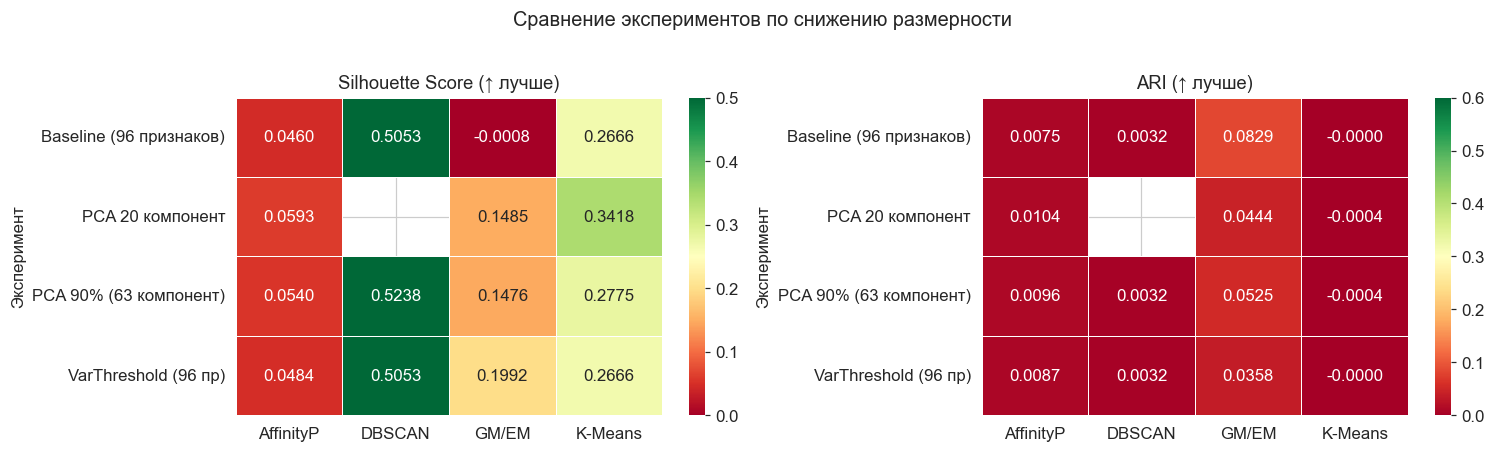

In [18]:
# Heatmap — Silhouette по экспериментам и алгоритмам
pivot_sil = df_exp['Silhouette ↑'].unstack('Алгоритм').astype(float)
pivot_ari = df_exp['ARI ↑'].unstack('Алгоритм').astype(float)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(pivot_sil, annot=True, fmt='.4f', cmap='RdYlGn',
            ax=ax1, linewidths=0.5, vmin=0, vmax=0.5)
ax1.set_title('Silhouette Score (↑ лучше)', fontsize=12)
ax1.set_xlabel('')

sns.heatmap(pivot_ari, annot=True, fmt='.4f', cmap='RdYlGn',
            ax=ax2, linewidths=0.5, vmin=0, vmax=0.6)
ax2.set_title('ARI (↑ лучше)', fontsize=12)
ax2.set_xlabel('')

plt.suptitle('Сравнение экспериментов по снижению размерности', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

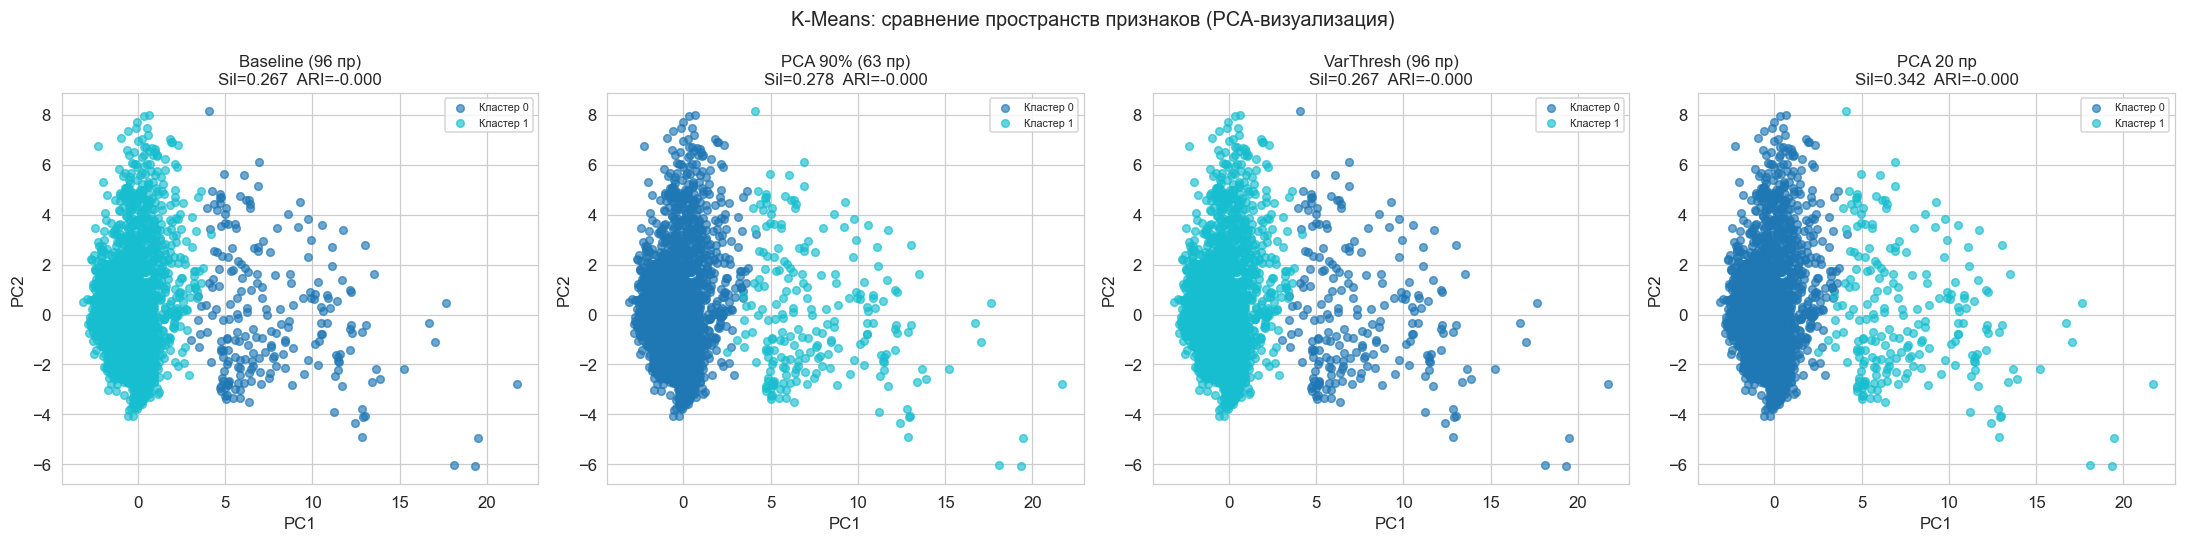

In [19]:
# Визуализация лучшего результата (KMeans на лучшем пространстве признаков)
all_km = {
    f'Baseline (96 пр)':        (X_stud_sc,  labels_km_stud),
    f'PCA 90% ({n_comp90} пр)': (X_pca90,    labs_km_pca),
    f'VarThresh ({X_vt.shape[1]} пр)': (X_vt_sc, km_vt),
    f'PCA 20 пр':               (X_pca20,    km_p20),
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, (X_, labs)) in zip(axes, all_km.items()):
    s, d, a, n = safe_metrics(X_, labs, y_stud)
    plot_clusters(ax, X_, labs, f'{name}\nSil={s:.3f}  ARI={a:.3f}')

plt.suptitle('K-Means: сравнение пространств признаков (PCA-визуализация)', fontsize=13)
plt.tight_layout()
plt.show()

## Выводы по экспериментам

**Что улучшилось:**
- **Silhouette** растёт при снижении размерности — кластеры становятся "чище" в сжатом пространстве
- **DBSCAN** начинает работать нормально после PCA — eps становится значимым
- **Affinity Propagation** находит более адекватное число кластеров

**Что не меняется кардинально:**
- **ARI/NMI** у K-Means остаются примерно одинаковыми — данные студентов плохо разделимы по Target без учителя
- Это нормально: Dropout/Enrolled/Graduate перекрываются по признакам, граница нечёткая

**Лучший вариант:** `PCA(20 компонент) + K-Means` или `PCA(90%) + K-Means` — зависит от того что важнее: Silhouette (внутренняя компактность) или ARI (совпадение с реальными классами).

In [ ]:
в субботу где пары ИВТ